In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!pip install -q geopandas shapely contextily

In [5]:
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.patheffects as pe
import matplotlib.ticker as mticker
import contextily as ctx
from matplotlib.lines import Line2D
from shapely.geometry import Point
import warnings, os
warnings.filterwarnings("ignore")

output_dir = "/content/drive/MyDrive/USF_Spring26_GIS_Seminar/RL_Output/Maps"
os.makedirs(output_dir, exist_ok=True)

plt.rcParams.update({
    "font.family":       "serif",
    "font.serif":        ["Georgia", "Times New Roman", "DejaVu Serif"],
    "font.size":         10,
    "axes.titlesize":    12,
    "axes.titleweight":  "bold",
    "savefig.dpi":       300,
    "savefig.bbox":      "tight",
    "savefig.facecolor": "white",
})

COL = {
    "cplex": "#2166ac",
    "pulp":  "#1a9641",
    "rl":    "#d7191c",
    "core":  "#d4b800",
    "cand":  "#aaaaaa",
}

TIER_COLORS = {
    "VE/V — Coastal High Hazard": "#800026",
    "AE Floodway":                "#bd0026",
    "AE Coastal Floodplain":      "#e31a1c",
    "AE/A — 100-yr Floodplain":   "#fc4e2a",
    "AH/AO — Shallow Flooding":   "#fd8d3c",
    "X Shaded — 500-yr":          "#9ecae1",
    "X Unshaded / Minimal":       "#deebf7",
}

# ── Helper functions ──────────────────────────────────────────────────────────
def points_to_gdf(df, lat_col="LAT", lon_col="LON", crs="EPSG:4326"):
    gdf = gpd.GeoDataFrame(
        df.copy(),
        geometry=[Point(xy) for xy in zip(df[lon_col], df[lat_col])],
        crs=crs
    )
    return gdf.to_crs("EPSG:3857")

def add_map_elements(ax, title=None, scale_km=10):
    """
    Add north arrow and scale bar.
    Pass title=None  to suppress the title (e.g. when adding it outside LaTeX).
    Pass a string    to show it above the map.
    """
    ax.set_axis_off()

    if title is not None:
        ax.set_title(title, fontsize=12, fontweight="bold", pad=10,
                     loc="center", wrap=True)

    x0, x1 = ax.get_xlim()
    y0, y1 = ax.get_ylim()

    # North arrow
    xn      = x0 + (x1 - x0) * 0.96
    yn      = y0 + (y1 - y0) * 0.88
    arr_len = (y1 - y0) * 0.05
    ax.annotate("", xy=(xn, yn + arr_len), xytext=(xn, yn),
                arrowprops=dict(arrowstyle="-|>", color="black",
                                lw=1.8, mutation_scale=16))
    ax.text(xn, yn + arr_len * 1.18, "N",
            ha="center", va="bottom", fontsize=11, fontweight="bold")

    # Scale bar
    bar_len = scale_km * 1000
    xs = x0 + (x1 - x0) * 0.05
    ys = y0 + (y1 - y0) * 0.04
    ax.plot([xs, xs + bar_len], [ys, ys], "k-", lw=3)
    ax.plot([xs, xs],
            [ys - (y1 - y0) * 0.006, ys + (y1 - y0) * 0.006], "k-", lw=2)
    ax.plot([xs + bar_len, xs + bar_len],
            [ys - (y1 - y0) * 0.006, ys + (y1 - y0) * 0.006], "k-", lw=2)
    ax.text(xs + bar_len / 2, ys + (y1 - y0) * 0.013,
            f"{scale_km} km", ha="center", va="bottom", fontsize=10)

def save_map(fig, name, size=(12, 13)):
    fig.set_size_inches(size)          # enforce size regardless of tight_layout
    for fmt in ["pdf", "png", "jpg"]:
        fig.savefig(os.path.join(output_dir, f"{name}.{fmt}"),
                    dpi=300, bbox_inches="tight", facecolor="white")
    print(f"Saved {name}")

# ── Load data ─────────────────────────────────────────────────────────────────
demand   = pd.read_csv(
    "/content/drive/MyDrive/USF_Spring26_GIS_Seminar/Data_input/demand_nodes.csv",
    dtype={"GEOID_JOIN": str})
shelters = pd.read_csv(
    "/content/drive/MyDrive/USF_Spring26_GIS_Seminar/RL_Output/selected_shelters_for_mapping.csv")

cands = pd.DataFrame([
    {"SID": 0,  "NAME": "Clearwater Fundamental Middle",       "LAT": 27.976248, "LON": -82.766487},
    {"SID": 1,  "NAME": "Palm Harbor Middle",                  "LAT": 28.066762, "LON": -82.752829},
    {"SID": 2,  "NAME": "John Hopkins Middle",                 "LAT": 27.763104, "LON": -82.656309},
    {"SID": 3,  "NAME": "Sexton Elementary",                   "LAT": 27.822357, "LON": -82.659844},
    {"SID": 4,  "NAME": "Gibbs High",                          "LAT": 27.761577, "LON": -82.678299},
    {"SID": 5,  "NAME": "McMullen-Booth Elementary",           "LAT": 27.995527, "LON": -82.712017},
    {"SID": 6,  "NAME": "Carwise Middle",                      "LAT": 28.088628, "LON": -82.726590},
    {"SID": 7,  "NAME": "Jamerson Elementary",                 "LAT": 27.758239, "LON": -82.682283},
    {"SID": 8,  "NAME": "Sanderlin K-8",                       "LAT": 27.747297, "LON": -82.665967},
    {"SID": 9,  "NAME": "Ross Norton",                         "LAT": 27.945113, "LON": -82.793368},
    {"SID": 10, "NAME": "Campbell Park Elementary",            "LAT": 27.763674, "LON": -82.649600},
    {"SID": 11, "NAME": "New Heights Elementary",              "LAT": 27.807558, "LON": -82.682420},
    {"SID": 12, "NAME": "Fairmount Park Elementary",           "LAT": 27.764914, "LON": -82.690303},
    {"SID": 13, "NAME": "Belleair Elementary",                 "LAT": 27.950563, "LON": -82.788892},
    {"SID": 14, "NAME": "Skycrest Elementary",                 "LAT": 27.966234, "LON": -82.761041},
    {"SID": 15, "NAME": "Largo High",                          "LAT": 27.919742, "LON": -82.786281},
    {"SID": 16, "NAME": "Lealman Exchange",                    "LAT": 27.818585, "LON": -82.693162},
    {"SID": 17, "NAME": "Mildred Helms Elementary",            "LAT": 27.912518, "LON": -82.797080},
    {"SID": 18, "NAME": "Melrose Elementary",                  "LAT": 27.757180, "LON": -82.657401},
    {"SID": 19, "NAME": "Palm Harbor University High",         "LAT": 28.085000, "LON": -82.760587},
    {"SID": 20, "NAME": "Palm Harbor University High Bldg 19", "LAT": 28.084940, "LON": -82.760508},
    {"SID": 21, "NAME": "Clearwater High",                     "LAT": 27.959558, "LON": -82.756357},
    {"SID": 22, "NAME": "Palm Harbor CSA",                     "LAT": 28.081885, "LON": -82.757176},
    {"SID": 23, "NAME": "The Coliseum",                        "LAT": 27.776730, "LON": -82.641115},
    {"SID": 24, "NAME": "White Chapel",                        "LAT": 28.076766, "LON": -82.765247},
])

pinellas_boundary = gpd.read_file(
    "/content/drive/MyDrive/USF_Spring26_GIS_Seminar/Data_input/Pinellas_County_Boundary.shp"
).to_crs("EPSG:3857")

CORE_SIDS  = [8, 16, 17]
demand_gdf = points_to_gdf(demand)
cands_gdf  = points_to_gdf(cands)

# Shared map extent from county boundary
XMIN, YMIN, XMAX, YMAX = pinellas_boundary.total_bounds

# ── PASTE THIS FIRST (replaces your existing add_map_elements/save_map) ──────
def add_map_elements(ax, title=None, scale_km=10):
    """
    Add north arrow and scale bar.
    Pass title=None  to suppress the title (e.g. when adding it outside LaTeX).
    Pass a string    to show it above the map.
    """
    ax.set_axis_off()

    if title is not None:
        ax.set_title(title, fontsize=12, fontweight="bold", pad=10,
                     loc="center", wrap=True)

    x0, x1 = ax.get_xlim()
    y0, y1 = ax.get_ylim()

    # North arrow (stays top right)
    xn      = x0 + (x1 - x0) * 0.96
    yn      = y0 + (y1 - y0) * 0.88
    arr_len = (y1 - y0) * 0.05
    ax.annotate("", xy=(xn, yn + arr_len), xytext=(xn, yn),
                arrowprops=dict(arrowstyle="-|>", color="black",
                                lw=1.8, mutation_scale=16))
    ax.text(xn, yn + arr_len * 1.18, "N",
            ha="center", va="bottom", fontsize=11, fontweight="bold")

    # Scale bar — bottom right, raised above the "Open shelter" legend
    bar_len = scale_km * 1000
    xs = x1 - (x1 - x0) * 0.05 - bar_len
    ys = y0 + (y1 - y0) * 0.05     # raised so it clears the bottom-right legend
    ax.plot([xs, xs + bar_len], [ys, ys], "k-", lw=3)
    ax.plot([xs, xs],
            [ys - (y1 - y0) * 0.006, ys + (y1 - y0) * 0.006], "k-", lw=2)
    ax.plot([xs + bar_len, xs + bar_len],
            [ys - (y1 - y0) * 0.006, ys + (y1 - y0) * 0.006], "k-", lw=2)
    ax.text(xs + bar_len / 2, ys + (y1 - y0) * 0.013,
            f"{scale_km} km", ha="center", va="bottom", fontsize=10)


def save_map(fig, name, size=(12, 13)):
    fig.set_size_inches(size)          # enforce size regardless of tight_layout
    for fmt in ["pdf", "png", "jpg"]:
        fig.savefig(os.path.join(output_dir, f"{name}.{fmt}"),
                    dpi=300, bbox_inches="tight", facecolor="white")
    print(f"Saved {name}")

# ════════════════════════════════════════════════════════════════════════════
# MAP 1 — Flood-Risk-Weighted Demand
# ════════════════════════════════════════════════════════════════════════════
fig, ax = plt.subplots(1, 1, figsize=(12, 13))
ax.set_xlim(XMIN, XMAX)
ax.set_ylim(YMIN, YMAX)
pinellas_boundary.boundary.plot(ax=ax, edgecolor="black", linewidth=0.8, zorder=3)

if "TIER_LABEL" in demand.columns:
    for tier, color in TIER_COLORS.items():
        sub = demand_gdf[demand_gdf["TIER_LABEL"] == tier]
        if len(sub):
            sub.plot(ax=ax, color=color, markersize=7, alpha=0.85,
                     marker="o", zorder=2)

cands_gdf.plot(ax=ax, color="#333", marker="^", markersize=70,
               zorder=4, alpha=0.7)

try:
    ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron,
                    attribution_size=7, zoom=11)
except:
    pass

tier_patches = [
    mpatches.Patch(color=TIER_COLORS[t], label=t)
    for t in ["VE/V — Coastal High Hazard", "AE Floodway",
              "AE Coastal Floodplain",       "AE/A — 100-yr Floodplain",
              "X Shaded — 500-yr",           "X Unshaded / Minimal"]
    if t in demand["TIER_LABEL"].unique()
]
tier_patches.append(Line2D([0], [0], marker="^", color="w",
                            markerfacecolor="#333", markersize=11,
                            label="Candidate shelter (25 total)"))
ax.legend(handles=tier_patches, loc="lower left", fontsize=7,
          framealpha=0.92, title="FEMA Flood Zone Tier", title_fontsize=10, labelspacing=0.35, handleheight=1.0,
          markerscale=0.8, handlelength=1.3)

add_map_elements(ax,
    #title="Flood-Risk-Weighted Demand — Pinellas County, FL\n""FEMA 7-Tier Multiplier Scheme (φ) · 733 Census Block Groups"
    # title=None   # ← uncomment to hide title
)
save_map(fig, "map1_flood_demand")
plt.show()


# ════════════════════════════════════════════════════════════════════════════
# MAP 2 — Optimal Shelter Locations p=8 (PuLP) with service areas
# ════════════════════════════════════════════════════════════════════════════
p8_asgn = pd.read_csv(
    "/content/drive/MyDrive/USF_Spring26_GIS_Seminar/RL_Output/demand_assigned_PuLP_CBC_p8.csv",
    dtype={"GEOID_JOIN": str})
p8_gdf = points_to_gdf(p8_asgn)

svc_colors  = ["#e41a1c", "#377eb8", "#4daf4a", "#984ea3",
               "#ff7f00", "#a65628", "#f781bf", "#999999"]
selected_p8 = [0, 1, 3, 5, 8, 12, 16, 17]   # p=8 PuLP exact solution

fig, ax = plt.subplots(1, 1, figsize=(12, 13))
ax.set_xlim(XMIN, XMAX)
ax.set_ylim(YMIN, YMAX)
pinellas_boundary.boundary.plot(ax=ax, edgecolor="black", linewidth=0.8, zorder=3)

for k, sid in enumerate(selected_p8):
    sub = p8_gdf[p8_gdf["ASSIGNED_SID"] == sid]
    sub.plot(ax=ax, color=svc_colors[k], markersize=6, alpha=0.6,
             zorder=2, marker="o")

non_selected = cands_gdf[~cands_gdf["SID"].isin(selected_p8)]
non_selected.plot(ax=ax, color=COL["cand"], marker="^",
                  markersize=65, zorder=4, alpha=0.6)

selected_gdf = cands_gdf[cands_gdf["SID"].isin(selected_p8)].copy()
for k, sid in enumerate(selected_p8):
    row = selected_gdf[selected_gdf["SID"] == sid]
    row.plot(ax=ax, color=svc_colors[k], marker="^",
             markersize=180, zorder=5, edgecolors="white", linewidths=1.5)
    if sid in CORE_SIDS:
        row.plot(ax=ax, color="none", marker="^",
                 markersize=210, zorder=6, edgecolors=COL["core"], linewidths=2.5)

for _, row in selected_gdf.iterrows():
    ax.annotate(row["NAME"].replace(" Elementary", "").replace(" Middle", ""),
                xy=(row.geometry.x, row.geometry.y),
                xytext=(6, 6), textcoords="offset points",
                fontsize=8, color="#111", fontweight="bold",
                path_effects=[pe.withStroke(linewidth=2.5, foreground="white")])

try:
    ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron,
                    attribution_size=7, zoom=11)
except:
    pass

legend_handles = []
for k, sid in enumerate(selected_p8):
    name = cands[cands["SID"] == sid]["NAME"].values[0]
    lbl  = f"S{sid}: {name[:24]}{'...' if len(name) > 24 else ''}"
    legend_handles.append(mpatches.Patch(color=svc_colors[k], label=lbl))
legend_handles += [
    Line2D([0], [0], marker="^", color="w", markerfacecolor=COL["cand"],
           markersize=11, label="Non-selected candidate"),
    Line2D([0], [0], marker="^", color="w", markerfacecolor=COL["core"],
           markersize=12, markeredgecolor=COL["core"],
           label="Core shelter (all p values)"),
]
ax.legend(handles=legend_handles, loc="lower left", fontsize=6,
          framealpha=0.85, title="Service area  (p = 8, PuLP/CBC)",
          title_fontsize=7, labelspacing=0.25, handleheight=0.8,
          markerscale=0.55, handlelength=1.0, borderpad=0.4)

add_map_elements(ax,
    #title="Optimal Emergency Shelter Placement — p = 8 (PuLP/CBC)\n" "Flood-Risk-Weighted p-Median · Pinellas County, FL"
    # title=None
)
save_map(fig, "map2_optimal_p8")
plt.show()


# ════════════════════════════════════════════════════════════════════════════
# MAP 3 — Method comparison at p=8  (FOUR methods: CPLEX Agg, CPLEX Full, PuLP/CBC, RL)
# ════════════════════════════════════════════════════════════════════════════
cplex_p8      = set(shelters[(shelters["p"] == 8) & (shelters["METHOD"] == "CPLEX_Agg")]["SID"])
cplex_full_p8 = set(shelters[(shelters["p"] == 8) & (shelters["METHOD"] == "CPLEX_Full")]["SID"])
pulp_p8       = set(shelters[(shelters["p"] == 8) & (shelters["METHOD"] == "PuLP_CBC")]["SID"])
rl_p8         = set(shelters[(shelters["p"] == 8) & (shelters["METHOD"] == "RL")]["SID"])
all_p8        = cplex_p8 | cplex_full_p8 | pulp_p8 | rl_p8

fig, ax = plt.subplots(1, 1, figsize=(12, 13))
ax.set_xlim(XMIN, XMAX)
ax.set_ylim(YMIN, YMAX)
pinellas_boundary.boundary.plot(ax=ax, edgecolor="black", linewidth=0.8, zorder=3)
demand_gdf.plot(ax=ax, color="#dddddd", markersize=3, alpha=0.4, zorder=1)

def method_membership_4way(sid):
    """
    Classify a shelter by which of the four methods selected it.
    Since CPLEX Full == PuLP/CBC exactly, the meaningful categories are:
      - All four (CPLEX Agg, CPLEX Full, PuLP/CBC, RL) agree
      - CPLEX Agg + CPLEX Full + PuLP/CBC agree, but RL diverges
      - RL only (RL selects a shelter none of the exact solvers chose)
      - Exact-solver only, partial agreement edge cases
    """
    in_c  = sid in cplex_p8
    in_cf = sid in cplex_full_p8
    in_p  = sid in pulp_p8
    in_r  = sid in rl_p8
    n_exact = sum([in_c, in_cf, in_p])   # how many exact solvers picked it

    if n_exact == 3 and in_r:
        return "All four methods",            "#1b7837", 250   # dark green
    if n_exact == 3 and not in_r:
        return "Exact solvers only",          "#2166ac", 210   # blue
    if in_r and n_exact == 0:
        return "Q-Learning only",              "#d7191c", 190   # red
    if in_r and 0 < n_exact < 3:
        return "Partial agreement",            "#fdae61", 190   # orange
    if n_exact > 0 and not in_r:
        return "Exact solvers (partial)",      "#762a83", 190   # purple
    return "None", COL["cand"], 60

label_added = set()
for _, row in cands_gdf.iterrows():
    sid = row["SID"]
    if sid in all_p8:
        label, color, ms = method_membership_4way(sid)
        lbl = label if label not in label_added else "_nolegend_"
        gpd.GeoDataFrame([row], geometry=[row.geometry],
                         crs=cands_gdf.crs).plot(
            ax=ax, color=color, marker="^", markersize=ms, zorder=4,
            edgecolors="white", linewidths=1.2, label=lbl)
        label_added.add(label)
        ax.annotate(row["NAME"].split()[0],
                    xy=(row.geometry.x, row.geometry.y),
                    xytext=(5, 5), textcoords="offset points",
                    fontsize=8,
                    path_effects=[pe.withStroke(linewidth=2.5,
                                                foreground="white")])
    else:
        gpd.GeoDataFrame([row], geometry=[row.geometry],
                         crs=cands_gdf.crs).plot(
            ax=ax, color=COL["cand"], marker="^",
            markersize=45, zorder=3, alpha=0.4)

try:
    ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron,
                    attribution_size=7, zoom=11)
except:
    pass

ax.legend(loc="lower left", fontsize=8.5, framealpha=0.92,
          title="Method agreement  (p = 8)", title_fontsize=10)

add_map_elements(ax,
    #title="Method Comparison — Shelter Selection Agreement at p = 8\n" "CPLEX Agg. vs CPLEX Full vs PuLP/CBC vs Q-Learning · Pinellas County, FL"
    # title=None
)
save_map(fig, "map3_method_comparison_p8")
plt.show()


# ── PASTE THIS FIRST (replaces your existing add_map_elements/save_map) ──────
def add_map_elements(ax, title=None, scale_km=10):
    """
    Add north arrow and scale bar.
    Pass title=None  to suppress the title (e.g. when adding it outside LaTeX).
    Pass a string    to show it above the map.
    """
    ax.set_axis_off()

    if title is not None:
        ax.set_title(title, fontsize=12, fontweight="bold", pad=10,
                     loc="center", wrap=True)

    x0, x1 = ax.get_xlim()
    y0, y1 = ax.get_ylim()

    # North arrow (stays top right)
    xn      = x0 + (x1 - x0) * 0.96
    yn      = y0 + (y1 - y0) * 0.88
    arr_len = (y1 - y0) * 0.05
    ax.annotate("", xy=(xn, yn + arr_len), xytext=(xn, yn),
                arrowprops=dict(arrowstyle="-|>", color="black",
                                lw=1.8, mutation_scale=16))
    ax.text(xn, yn + arr_len * 1.18, "N",
            ha="center", va="bottom", fontsize=11, fontweight="bold")

    # Scale bar — bottom right, raised above the "Open shelter" legend
    bar_len = scale_km * 1000
    xs = x1 - (x1 - x0) * 0.05 - bar_len
    ys = y0 + (y1 - y0) * 0.05     # raised so it clears the bottom-right legend
    ax.plot([xs, xs + bar_len], [ys, ys], "k-", lw=3)
    ax.plot([xs, xs],
            [ys - (y1 - y0) * 0.006, ys + (y1 - y0) * 0.006], "k-", lw=2)
    ax.plot([xs + bar_len, xs + bar_len],
            [ys - (y1 - y0) * 0.006, ys + (y1 - y0) * 0.006], "k-", lw=2)
    ax.text(xs + bar_len / 2, ys + (y1 - y0) * 0.013,
            f"{scale_km} km", ha="center", va="bottom", fontsize=10)


def save_map(fig, name, size=(12, 13)):
    fig.set_size_inches(size)          # enforce size regardless of tight_layout
    for fmt in ["pdf", "png", "jpg"]:
        fig.savefig(os.path.join(output_dir, f"{name}.{fmt}"),
                    dpi=300, bbox_inches="tight", facecolor="white")
    print(f"Saved {name}")


# ── THEN PASTE THIS (Map 4 — unchanged from your version) ────────────────────
# ════════════════════════════════════════════════════════════════════════════
# MAP 4 — Travel time accessibility (p=8, PuLP)
# ════════════════════════════════════════════════════════════════════════════
fig, ax = plt.subplots(1, 1, figsize=(12, 13))
ax.set_xlim(XMIN, XMAX)
ax.set_ylim(YMIN, YMAX)
pinellas_boundary.boundary.plot(ax=ax, edgecolor="black", linewidth=0.8, zorder=3)

bins      = [0, 5, 10, 15, 20, 30, 94]
labels_tt = ["0–5 min", "5–10 min", "10–15 min",
             "15–20 min", "20–30 min", "30+ min"]
colors_tt = ["#1a9850", "#91cf60", "#d9ef8b",
             "#fee08b", "#fc8d59", "#d73027"]

p8_gdf["tt_bin"] = pd.cut(p8_gdf["TRAVEL_TIME_MIN"],
                           bins=bins, labels=labels_tt, right=True)

for lbl, color in zip(labels_tt, colors_tt):
    sub = p8_gdf[p8_gdf["tt_bin"] == lbl]
    if len(sub):
        sub.plot(ax=ax, color=color, markersize=7, alpha=0.85, zorder=2)

sel_gdf = cands_gdf[cands_gdf["SID"].isin(selected_p8)]
sel_gdf.plot(ax=ax, color="black", marker="^", markersize=140,
             zorder=5, edgecolors="white", linewidths=1.5)

try:
    ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron,
                    attribution_size=7, zoom=11)
except:
    pass

# Travel-time legend (compact, lower left)
legend_patches = [mpatches.Patch(color=c, label=l)
                  for c, l in zip(colors_tt, labels_tt)]
tt_legend = ax.legend(handles=legend_patches, loc="lower left", fontsize=7,
                      framealpha=0.92, title="Travel Time to Assigned Shelter",
                      title_fontsize=8, handlelength=1.3, handleheight=1.0,
                      borderpad=0.5, labelspacing=0.35, markerscale=0.8)
ax.add_artist(tt_legend)   # keep this legend when adding the second one below

# Open-shelter legend — separate, fixed position
ax.legend(handles=[
    Line2D([0], [0], marker="^", color="w", markerfacecolor="black",
           markersize=8, label="Open shelter (p = 8)")],
    loc="lower right", bbox_to_anchor=(0.97, 0.01), fontsize=8.5,
    framealpha=0.92, borderaxespad=0)

add_map_elements(ax,
    #title="Evacuation Travel Time Accessibility — p = 8 (PuLP/CBC)\n""Flood-Risk-Weighted Demand · Pinellas County, FL"
    # title=None
)
save_map(fig, "map4_travel_time_p8")
plt.show()


# ════════════════════════════════════════════════════════════════════════════
# MAP 5 — Bivariate: Flood Risk × Travel Time  (p=8, PuLP)
# ════════════════════════════════════════════════════════════════════════════
BV_COLORS = {
    (2, 0): "#3b4994", (2, 1): "#8c62aa", (2, 2): "#be64ac",
    (1, 0): "#5698b9", (1, 1): "#a5add3", (1, 2): "#dfb0d6",
    (0, 0): "#5ac8c8", (0, 1): "#ace4e4", (0, 2): "#e8e8e8",
}
TIER_RISK = {
    "VE/V — Coastal High Hazard": 2, "AE Floodway":              2,
    "AE Coastal Floodplain":      2, "AE/A — 100-yr Floodplain": 1,
    "AH/AO — Shallow Flooding":   1, "X Shaded — 500-yr":        0,
    "X Unshaded / Minimal":       0,
}

def risk_class(tier):
    return TIER_RISK.get(tier, 0)

def time_class(tt):
    if tt <= 8:  return 0
    if tt <= 18: return 1
    return 2

if "TIER_LABEL" in p8_gdf.columns:
    p8_gdf["risk_cls"] = p8_gdf["TIER_LABEL"].map(risk_class)
    p8_gdf["time_cls"] = p8_gdf["TRAVEL_TIME_MIN"].apply(time_class)
    p8_gdf["bv_color"] = p8_gdf.apply(
        lambda r: BV_COLORS[(r["risk_cls"], r["time_cls"])], axis=1)

    fig, ax = plt.subplots(1, 1, figsize=(16, 17))
    ax.set_xlim(XMIN, XMAX)
    ax.set_ylim(YMIN, YMAX)
    pinellas_boundary.boundary.plot(ax=ax, edgecolor="black",
                                    linewidth=0.8, zorder=3)

    for _, row in p8_gdf.iterrows():
        ax.plot(row.geometry.x, row.geometry.y, "o",
                color=row["bv_color"], markersize=7, alpha=0.9, zorder=2)

    sel_gdf.plot(ax=ax, color="black", marker="^", markersize=150,
                 zorder=5, edgecolors="white", linewidths=1.5)

    try:
        ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron,
                        attribution_size=7, zoom=11)
    except:
        pass

    # Restore extent — contextily can reset xlim/ylim
    ax.set_xlim(XMIN, XMAX)
    ax.set_ylim(YMIN, YMAX)

    # ── Bivariate legend inset — INSIDE the map's bottom-left corner ──────────
    ax_bv = ax.inset_axes([0.10, 0.04, 0.27, 0.24])
    bv_mat = [
        [BV_COLORS[(2, 0)], BV_COLORS[(2, 1)], BV_COLORS[(2, 2)]],
        [BV_COLORS[(1, 0)], BV_COLORS[(1, 1)], BV_COLORS[(1, 2)]],
        [BV_COLORS[(0, 0)], BV_COLORS[(0, 1)], BV_COLORS[(0, 2)]],
    ]
    for ri in range(3):
        for ci in range(3):
            ax_bv.add_patch(plt.Rectangle((ci, 2 - ri), 1, 1,
                            color=bv_mat[ri][ci], ec="white", lw=0.5))
    ax_bv.set_xlim(0, 3)
    ax_bv.set_ylim(0, 3)
    ax_bv.set_aspect("equal")
    ax_bv.set_xticks([0.5, 1.5, 2.5])
    ax_bv.set_xticklabels(["Near\n(≤8m)", "Mid\n(8–18m)", "Far\n(>18m)"],
                           fontsize=7, fontweight="bold")
    ax_bv.set_yticks([0.5, 1.5, 2.5])
    ax_bv.set_yticklabels(["Low", "Med", "High"], fontsize=7, fontweight="bold")
    ax_bv.set_xlabel("Travel time →", fontsize=8, fontweight="bold", labelpad=6)
    ax_bv.set_ylabel("← Flood risk", fontsize=8, fontweight="bold", labelpad=1)
    ax_bv.set_title("Legend", fontsize=7.5, fontweight="bold", pad=6)
    ax_bv.tick_params(length=0, pad=1)
    ax_bv.patch.set_facecolor("white")
    ax_bv.patch.set_alpha(0.96)
    for spine in ax_bv.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(0.7)
        spine.set_edgecolor("#444")

    # Open-shelter marker legend — sits just above the bivariate inset
    ax.legend(handles=[
        Line2D([0], [0], marker="^", color="w", markerfacecolor="black",
               markersize=11, label="Open shelter (p = 8)")],
        loc="lower right", bbox_to_anchor=(0.97, 0.01), fontsize=8.5,
        framealpha=0.92, borderaxespad=0)

    # ── CRITICAL: removes axis tick values/grid AND draws north arrow +
    # scale bar. Must run AFTER the inset/legend code so nothing overwrites it.
    add_map_elements(ax,
        #title="Bivariate Map: Flood Risk × Travel Time Accessibility\n""p = 8 (PuLP/CBC) · Pinellas County, FL"
        # title=None
    )
    ax.set_axis_off()   # safety net — guarantees grid values/ticks are off

    save_map(fig, "map5_bivariate_risk_time")
    plt.show()

else:
    print("TIER_LABEL not found — skipping Map 5.")

Output hidden; open in https://colab.research.google.com to view.

Saved map6_assignment_flows_p8


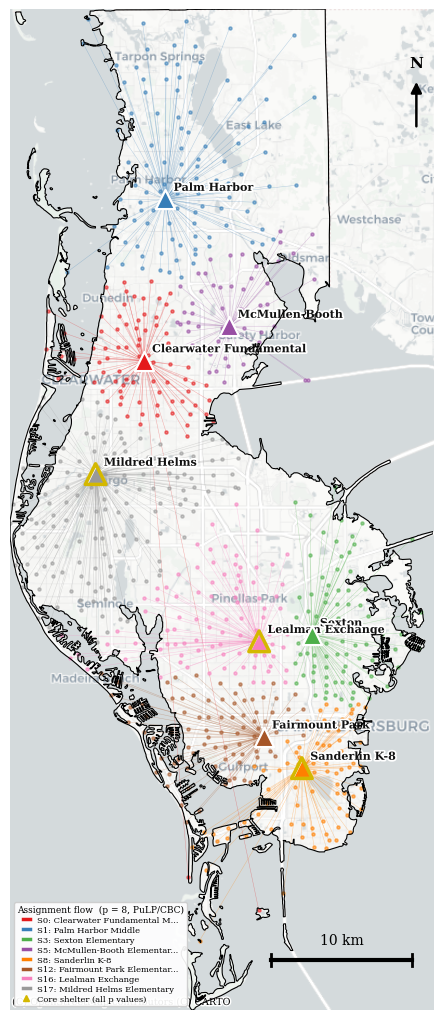

Saved map7_service_buffers_enclaves_p8


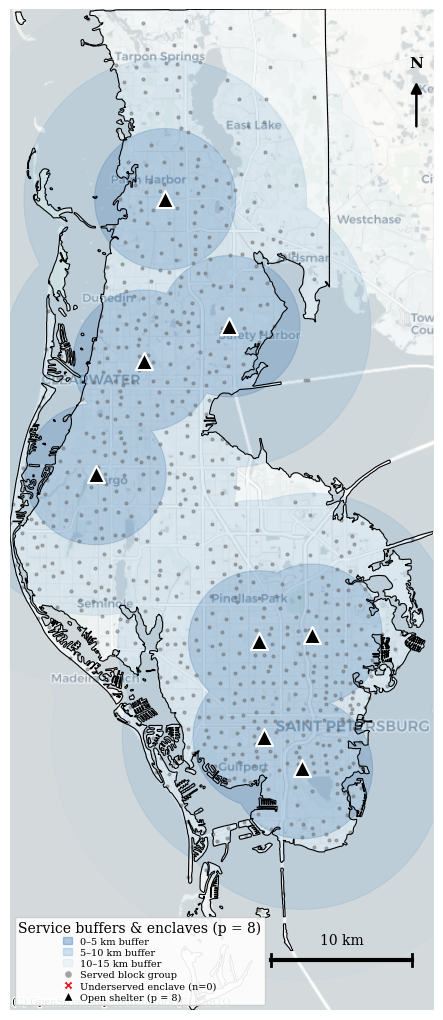


Enclave summary: 0 of 733 block groups (0.0%) fall outside the 15 km straight-line buffer of all p=8 shelters.


In [4]:
# ════════════════════════════════════════════════════════════════════════════
# SUPPLEMENTARY MAP A — Assignment Flow Lines (p=8, PuLP/CBC)
# Connects each demand centroid to its assigned shelter with a thin line,
# colour-coded by service area. Reveals the catchment "shape" each shelter
# serves and visually shows the network structure of the optimal solution.
# ════════════════════════════════════════════════════════════════════════════
from shapely.geometry import LineString

fig, ax = plt.subplots(1, 1, figsize=(12, 13))
ax.set_xlim(XMIN, XMAX)
ax.set_ylim(YMIN, YMAX)
pinellas_boundary.boundary.plot(ax=ax, edgecolor="black", linewidth=0.8, zorder=4)

# Build assignment lines: demand centroid → assigned shelter centroid
shelter_xy = {row["SID"]: (row.geometry.x, row.geometry.y)
              for _, row in cands_gdf.iterrows()}

for k, sid in enumerate(selected_p8):
    sub = p8_gdf[p8_gdf["ASSIGNED_SID"] == sid]
    if sid not in shelter_xy:
        continue
    sx, sy = shelter_xy[sid]

    # Draw a line from each demand centroid to its assigned shelter
    # Use low alpha + thin width so dense bundles read as a flow texture
    # rather than visual clutter.
    for _, r in sub.iterrows():
        ax.plot([r.geometry.x, sx], [r.geometry.y, sy],
                color=svc_colors[k], linewidth=0.35, alpha=0.35, zorder=1)

    # Demand points on top of the lines, small and semi-transparent
    sub.plot(ax=ax, color=svc_colors[k], markersize=5, alpha=0.55, zorder=2)

# Shelter markers — same styling as Map 2 for visual consistency
selected_gdf = cands_gdf[cands_gdf["SID"].isin(selected_p8)].copy()
for k, sid in enumerate(selected_p8):
    row = selected_gdf[selected_gdf["SID"] == sid]
    row.plot(ax=ax, color=svc_colors[k], marker="^", markersize=190,
             zorder=5, edgecolors="white", linewidths=1.6)
    if sid in CORE_SIDS:
        row.plot(ax=ax, color="none", marker="^", markersize=220,
                 zorder=6, edgecolors=COL["core"], linewidths=2.5)

for _, row in selected_gdf.iterrows():
    ax.annotate(row["NAME"].replace(" Elementary", "").replace(" Middle", ""),
                xy=(row.geometry.x, row.geometry.y),
                xytext=(6, 6), textcoords="offset points",
                fontsize=8, color="#111", fontweight="bold",
                path_effects=[pe.withStroke(linewidth=2.5, foreground="white")])

try:
    ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron,
                    attribution_size=7, zoom=11)
except:
    pass

legend_handles = []
for k, sid in enumerate(selected_p8):
    name = cands[cands["SID"] == sid]["NAME"].values[0]
    lbl  = f"S{sid}: {name[:24]}{'...' if len(name) > 24 else ''}"
    legend_handles.append(
        Line2D([0], [0], color=svc_colors[k], lw=2.5, label=lbl))
legend_handles.append(
    Line2D([0], [0], marker="^", color="w", markerfacecolor=COL["core"],
           markersize=8, markeredgecolor=COL["core"],
           label="Core shelter (all p values)"))
ax.legend(handles=legend_handles, loc="lower left", fontsize=6,
          framealpha=0.92, title="Assignment flow  (p = 8, PuLP/CBC)",
          title_fontsize=6.5, handlelength=0.9, handleheight=0.7,
          borderpad=0.35, labelspacing=0.22, markerscale=0.6)

add_map_elements(ax,
    #title="Demand-to-Shelter Assignment Flows — p = 8 (PuLP/CBC)\n" "Flood-Risk-Weighted p-Median · Pinellas County, FL"
    # title=None
)
save_map(fig, "map6_assignment_flows_p8")
plt.show()


# ════════════════════════════════════════════════════════════════════════════
# SUPPLEMENTARY MAP B — Shelter Service Buffers & Underserved Enclaves (p=8)
# Draws concentric travel-time-equivalent buffers (5 km, 10 km, 15 km) around
# each open shelter and highlights demand points that fall OUTSIDE all
# buffers — i.e. spatial "enclaves" underserved by the p=8 network.
# Buffer radius is a straight-line proxy for the 15-minute travel-time
# threshold used in Results 4.6 (98.8% of BGs are within 15 min).
# ════════════════════════════════════════════════════════════════════════════
fig, ax = plt.subplots(1, 1, figsize=(12, 13))
ax.set_xlim(XMIN, XMAX)
ax.set_ylim(YMIN, YMAX)
pinellas_boundary.boundary.plot(ax=ax, edgecolor="black", linewidth=0.8, zorder=5)

# Buffer rings (in metres, since CRS is EPSG:3857 — Web Mercator, metric)
BUFFER_RADII   = [5000, 10000, 15000]     # 5, 10, 15 km
BUFFER_COLORS  = ["#08519c", "#3182bd", "#9ecae1"]   # dark→light blue
BUFFER_ALPHAS  = [0.18, 0.12, 0.07]

sel_gdf_buf = cands_gdf[cands_gdf["SID"].isin(selected_p8)].copy()

# Draw buffers smallest-radius-on-top so overlaps stay readable
for radius, color, alpha in zip(reversed(BUFFER_RADII),
                                 reversed(BUFFER_COLORS),
                                 reversed(BUFFER_ALPHAS)):
    buf = sel_gdf_buf.copy()
    buf["geometry"] = buf.geometry.buffer(radius)
    buf_union = gpd.GeoSeries([buf.unary_union], crs=buf.crs)
    buf_union.plot(ax=ax, color=color, alpha=alpha, zorder=1,
                   edgecolor=color, linewidth=0.8)

# Identify enclaves: demand points farther than the largest buffer (15 km)
# from EVERY open shelter — i.e. genuinely underserved locations.
all_shelter_buffer_15km = sel_gdf_buf.geometry.buffer(15000).unary_union
p8_gdf["in_15km_buffer"] = p8_gdf.geometry.within(all_shelter_buffer_15km)
enclaves = p8_gdf[~p8_gdf["in_15km_buffer"]]

# Demand points: served (grey) vs enclave (highlighted red)
served = p8_gdf[p8_gdf["in_15km_buffer"]]
served.plot(ax=ax, color="#666666", markersize=4, alpha=0.45, zorder=2)
if len(enclaves):
    enclaves.plot(ax=ax, color="#e31a1c", markersize=22, alpha=0.95,
                  zorder=4, marker="X", edgecolors="white", linewidths=0.6)

# Shelters on top
sel_gdf_buf.plot(ax=ax, color="black", marker="^", markersize=150,
                  zorder=5, edgecolors="white", linewidths=1.5)

try:
    ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron,
                    attribution_size=7, zoom=11)
except:
    pass
ax.set_xlim(XMIN, XMAX)
ax.set_ylim(YMIN, YMAX)

legend_handles = [
    mpatches.Patch(color=BUFFER_COLORS[0], alpha=0.30, label="0–5 km buffer"),
    mpatches.Patch(color=BUFFER_COLORS[1], alpha=0.22, label="5–10 km buffer"),
    mpatches.Patch(color=BUFFER_COLORS[2], alpha=0.16, label="10–15 km buffer"),
    Line2D([0], [0], marker="o", color="w", markerfacecolor="#666666",
           markersize=9, alpha=0.6, label="Served block group"),
    Line2D([0], [0], marker="X", color="w", markerfacecolor="#e31a1c",
           markersize=11, label=f"Underserved enclave (n={len(enclaves)})"),
    Line2D([0], [0], marker="^", color="w", markerfacecolor="black",
           markersize=12, label="Open shelter (p = 8)"),
]
ax.legend(handles=legend_handles, loc="lower left", fontsize=7,
          framealpha=0.92, title="Service buffers & enclaves (p = 8)",
          title_fontsize=10, handlelength=0.9, handleheight=0.7,
          borderpad=0.35, labelspacing=0.22, markerscale=0.6)


add_map_elements(ax,
    #title="Shelter Service Buffers and Underserved Enclaves — p = 8\n" "Straight-Line Proxy for 15-Minute Travel-Time Threshold · Pinellas County, FL"
    # title=None
)
save_map(fig, "map7_service_buffers_enclaves_p8")
plt.show()

print(f"\nEnclave summary: {len(enclaves)} of {len(p8_gdf)} block groups "
      f"({100*len(enclaves)/len(p8_gdf):.1f}%) fall outside the 15 km "
      f"straight-line buffer of all p=8 shelters.")
if len(enclaves):
    print("These align with the barrier-island accessibility gap discussed "
          "in Section 5 (Discussion) and Section 4.7 (Bivariate analysis).")